# 16 — Structured masking on the real GAVD training partitions

Scattered targets often retain nearby time points and landmarks. Does
removing those clues encourage a useful movement representation?
We extend Notebook 11 by inspecting connected regions, full landmark
trajectories and interior gaps on **every real outer-training clip**,
for five folds and five seeds. Each structure gets its own scattered
reference with exactly the same realized target count.

[VideoMAE, NeurIPS 2022, §3.3](https://arxiv.org/html/2203.12602) repeats
spatial masks across frames, motivating full landmark trajectories here.
[I-JEPA, CVPR 2023, §3](https://arxiv.org/html/2301.08243v3) predicts
image regions from surrounding context. [SLiM, §3.3](https://arxiv.org/html/2603.10648v3)
masks connected anatomical subsets over consecutive time spans. Our
fixed region size and duration isolate a simpler skeleton comparison;
these are adaptations, not reproductions of those complete recipes.

### What to look for in the reviewed results — 2026-09-08

The saved figures establish that connected regions remove immediate
temporal brackets and reduce visible anatomical neighbors. Check whether
this intervention also improves readout: Notebook 18's completed region
comparison does not demonstrate a benefit. Section 6 below interprets the
actual audit, explains the different mask denominators, and prioritizes
the next investigation. All existing figures and tables are retained.

In [1]:
from pathlib import Path
from dataclasses import asdict, replace
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib_inline.backend_inline import set_matplotlib_formats

def locate_suite():
    for parent in (Path.cwd(), *Path.cwd().parents):
        for candidate in (parent, parent / "neurips-laterality"):
            if (candidate / "laterality_extensions/motion_structured_masks.py").is_file():
                return candidate.resolve()
    raise FileNotFoundError("Run from the research project directory.")

SUITE_ROOT = locate_suite()
if str(SUITE_ROOT) not in sys.path:
    sys.path.insert(0, str(SUITE_ROOT))
from laterality_extensions.motion_structured_masks import (
    StudyArm, mamp_logits, sample_study_mask, study_arms,
    paired_study_masks, context_cue_audit,
)
from laterality_extensions.comparative_masks import motion_scores
from notebook_progress import (
    NotebookTaskProgress, run_notebook_task, study_inputs_with_progress,
    audit_training_masks_with_progress, grid_status_with_progress,
    run_gavd_grid_with_progress, collect_gavd_grid_with_progress,
    evaluate_retained_motion_with_progress,
)
set_matplotlib_formats("svg", "png")
pd.set_option("display.precision", 3)

## 1. Load the real GAVD cohort and declare the full split/seed grid

Run cells in order in a Python kernel with the project's dependencies.
Long tasks use the shared `notebook_progress.py` wrapper: one updating
display shows the current stage, fold/seed, elapsed time and estimated
remaining time. Mask batches and optimizer updates appear within their
active stage. ETA adjusts as stages finish; their costs differ. Cached,
disabled, missing-input and failed tasks receive explicit status labels.
`DATA_MODE="gavd"` is the default. The helper below follows the same
preparation and source splitting functions as notebooks 01 and 02:

1. Verify an existing paper-profile cohort and split manifest by their
   content hashes. If absent, read the local GAVD pose archives and
   official annotations, apply the existing QC and target rules, and
   create those two artifacts. The first run takes longer.
2. The protocol fixes 642 pose archives and 666 annotations. If the local
   cache contains later additions, recover the original extraction
   generations only when their inventory **exactly** matches the locked
   count and SHA-256. Store verified copies under the paper artifact
   root. The original cache stays intact. A mismatch stops with an
   actionable error; it cannot silently switch to generated data.
3. The reference QC result is 625 clips from 93 source videos. Inputs have
   shape `[clips, 64, 33, 3]`; four prepared steps form each of 16 tokens
   per landmark. Naturally missing observations remain marked invalid.
   The target is a coordinate-derived bilateral movement contrast, not
   the dataset's condition annotation.
4. Reuse the five video-disjoint outer folds. Seeds 42--46 change
   initialization, source draws, augmentations and masks; they repeat
   the **same** train/test partitions. A video is held out exactly once
   per seed. There are 25 fold/seed combinations, not 25 independent
   datasets. Video separation does not establish subject separation.

The printed census makes train and test membership visible. Source IDs
and sequence IDs are retained in `inputs["memberships"]`. The reference
train/test clip counts are 436/189, 443/182, 553/72, 548/77 and 520/105.
Unequal clip counts are expected because entire videos stay together.

A small generated-data path remains available only through the explicit
`LATERALITY_MOTION_DATA_MODE=synthetic` software-check setting. It prints
its reduced scope and uses a separate artifact directory. It provides
no GAVD results. See [the run guide](docs/MOTION_GAVD_WORKFLOW.md) for
paths, environment settings, recovery and a notebook-by-notebook walkthrough.

In [2]:
from laterality_extensions.motion_gavd import gavd_plan, readout_contrasts
DATA_MODE = os.getenv("LATERALITY_MOTION_DATA_MODE", "gavd")
FOLDS = (0, 1, 2, 3, 4)
SEEDS = (42, 43, 44, 45, 46)
EXPERIMENTS = tuple(os.getenv("LATERALITY_MOTION_EXPERIMENTS", "motion,regions").split(","))
CREATE_MISSING_INPUTS = True
DEVICE = os.getenv("LATERALITY_DEVICE", "auto")
# Keep the numerical mode identical in Notebooks 17 and 18.
PRECISION = os.getenv("LATERALITY_MOTION_PRECISION", "fp32")  # or "bf16" on native CUDA BF16 hardware
RESUME_INTERVAL = int(os.getenv("LATERALITY_MOTION_RESUME_INTERVAL", "100"))
# Same explicit training switch as Notebook 12; also accept the study-specific alias.
RUN_TRAINING = os.getenv("LATERALITY_MOTION_RUN_REAL",
                        os.getenv("LATERALITY_RESEARCH_RUN_REAL", "0")) == "1"
if DATA_MODE == "synthetic":
    FOLDS, SEEDS = (0,), (42,)
    print("EXPLICIT SYNTHETIC SOFTWARE CHECK: one fold/seed, one update, no GAVD evidence")
OUTPUT_ROOT = Path(os.getenv("LATERALITY_MOTION_OUTPUT_ROOT", str(SUITE_ROOT / "artifacts" /
    ("motion_structured" if DATA_MODE == "gavd" else "motion_structured_synthetic"))))
print(f"Mode={DATA_MODE}; folds={FOLDS}; seeds={SEEDS}; device={DEVICE}")
print(f"Training enabled={RUN_TRAINING}; outputs={OUTPUT_ROOT}")

Mode=gavd; folds=(0, 1, 2, 3, 4); seeds=(42, 43, 44, 45, 46); device=cuda
Training enabled=True; outputs=C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\neurips-laterality\artifacts\motion_structured


In [3]:
input_progress = NotebookTaskProgress("Dataset preparation and source splits", "stage")
inputs = study_inputs_with_progress(mode=DATA_MODE, folds=FOLDS, seeds=SEEDS,
    create_missing=CREATE_MISSING_INPUTS, progress=input_progress)
display(inputs["census"])
assert inputs["census"].source_overlap.eq(0).all()
display(inputs["memberships"].head(8))
if DATA_MODE == "gavd":
    cohort = inputs["cohort"]
    display(cohort.table.groupby("condition").agg(
        accepted_clips=("sequence_id", "size"), source_videos=("video_id", "nunique")))
    display(pd.Series({key: cohort.attrition[key] for key in
        ("input_sequences", "accepted_sequences", "accepted_sources", "excluded_sequences")}))
    print("Cohort:", cohort.cohort_digest)
    print("Split:", inputs["splits"]["split_digest"])
    print("Artifacts:", inputs["context"].artifact_root)

,fold,seed,train_clips,test_clips,train_sources,test_sources,source_overlap,synthetic
0,0,42,436,189,74,19,0,False
1,0,43,436,189,74,19,0,False
2,0,44,436,189,74,19,0,False
3,0,45,436,189,74,19,0,False
4,0,46,436,189,74,19,0,False
5,1,42,443,182,74,19,0,False
6,1,43,443,182,74,19,0,False
7,1,44,443,182,74,19,0,False
8,1,45,443,182,74,19,0,False
9,1,46,443,182,74,19,0,False


,sequence_id,source_id,fold,seed,role
0,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,train
1,cljo2y1f7001e3n6lt1wgacw6,3KnFt8bH3tE,0,42,train
2,cljo2yqzp001i3n6lg75p7wtq,3KnFt8bH3tE,0,42,train
3,cljo2zn41001m3n6lhbvww48i,3KnFt8bH3tE,0,42,train
4,cljo30lnz001q3n6lopfty7q5,3KnFt8bH3tE,0,42,train
5,cljo32213001u3n6lel97up5f,3KnFt8bH3tE,0,42,train
6,cljo32ik2001y3n6lmmnu0sgo,3KnFt8bH3tE,0,42,train
7,cljo32xnz00223n6lvxzyif3y,3KnFt8bH3tE,0,42,train


,accepted_clips,source_videos
condition,,
cerebralpalsy,58,9
myopathic,183,28
normal,270,29
parkinsons,39,9
stroke,75,18


input_sequences       642
accepted_sequences    625
accepted_sources       93
excluded_sequences     17
dtype: int64

Cohort: bc23447824d2bc2bbe62dfdc7df5da8db7d1e73291d1675f2556597eeeefe2e3
Split: 0dd230e67d5eb583013ef6e4e295713d30e30799eea160adc8cb51b4db58eb1b
Artifacts: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\neurips-laterality\artifacts\paper\protocol_6f7baefbda07


## 2. Define three separate prediction problems

| Experiment | Structured target on complete 64-step input | Nominal tokens | Visible context |
|---|---|---:|---|
| `regions` (primary) | Six connected landmarks for eight blocks | 48 | Other landmarks and times |
| `trajectories` (follow-up) | Three landmarks for all 16 blocks | 48 | Other landmark trajectories |
| `completion` (follow-up) | All 33 landmarks for four interior blocks | 132 | Earlier and later observations |

Region definitions use anatomical graph connections from Notebook 11.
Their union covers all 33 landmarks. Array-neighboring IDs do not define
a body region; head-to-body links are explicit masking connections.

Missing observations reduce realized counts. The structured mask keeps
its geometry, then its scattered reference hides exactly that many valid
tokens in the same clip. No missing coordinate becomes a target. We do
not trim full trajectories to fit a count. A structure with no feasible
target/context fails before optimization.

The two nominally 48-token structures need not realize equal counts with
missing data. Completion has a different budget. Compare each against
its own reference; a raw cross-experiment ranking confounds geometry
with the amount of hidden information.

In [4]:
from laterality_extensions.comparative_masks import connected_region_bank
regions = connected_region_bank(tuple(range(33)), 6)
assert set().union(*map(set, regions)) == set(range(33))
print(f"{len(regions)} declared regions collectively cover all 33 landmarks.")
mask_progress = NotebookTaskProgress("Structured-mask audit", "fold/seed pass")
structure_audit = audit_training_masks_with_progress(inputs,
    experiments=("regions", "trajectories", "completion"), progress=mask_progress)
display(structure_audit["summary"])
assert structure_audit["per_clip"].groupby([
    "experiment", "fold", "seed", "sequence_id"]).hidden_tokens.nunique().eq(1).all()
print(f"Audited {len(structure_audit['per_clip']):,} training-clip mask draws.")

20 declared regions collectively cover all 33 landmarks.


,experiment,condition,fold,seed,clips,sources,hidden_min,hidden_max,hidden_tokens,hidden_fraction,target_motion,eligible_motion,both_legs_targeted,temporal_bracket_fraction,visible_neighbor_fraction
0,regions,uniform,0,42,436,74,18,48,47.471,0.099,0.135,0.136,1.000,0.701,0.988
1,regions,connected_region,0,42,436,74,18,48,47.471,0.099,0.114,0.136,0.208,0.000,0.503
2,trajectories,uniform,0,42,436,74,9,48,45.993,0.096,0.135,0.136,1.000,0.711,0.989
3,trajectories,whole_trajectory,0,42,436,74,9,48,45.993,0.096,0.139,0.136,0.131,0.000,0.998
4,completion,uniform,0,42,436,74,54,132,121.933,0.254,0.136,0.136,1.000,0.483,0.938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,regions,connected_region,4,46,520,75,22,48,47.574,0.101,0.124,0.141,0.176,0.000,0.491
146,trajectories,uniform,4,46,520,75,17,48,45.228,0.095,0.142,0.141,0.998,0.717,0.987
147,trajectories,whole_trajectory,4,46,520,75,17,48,45.228,0.095,0.145,0.141,0.132,0.000,0.996
148,completion,uniform,4,46,520,75,54,132,120.411,0.253,0.141,0.141,1.000,0.479,0.940


Audited 75,000 training-clip mask draws.


## 3. See what a real clip leaves available

Each row compares one structured family to its own uniform draw. Gray
marks natural missingness, blue visible context, and orange deliberate
targets. Panels identify the same first training clip selected before
outcome analysis. Geometry remains intact even when gray cells interrupt
its observed target support.

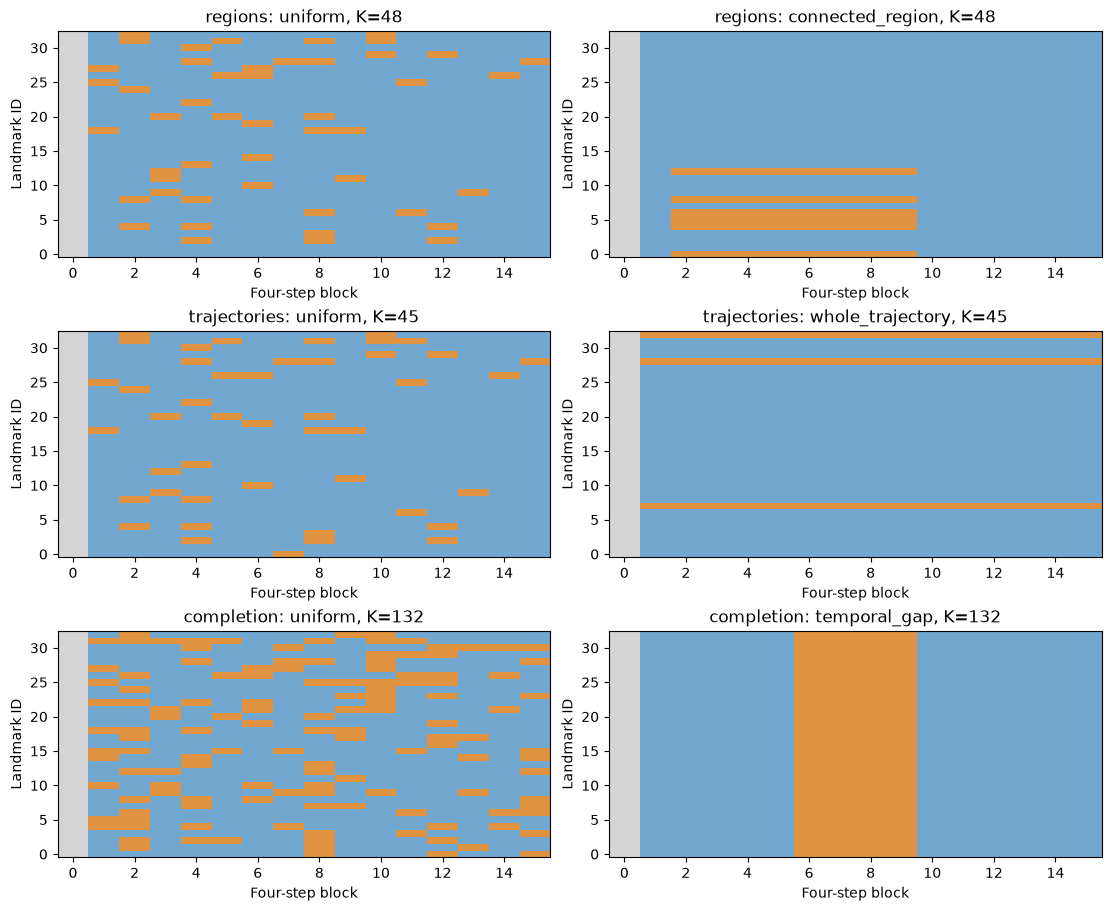

,experiment,condition,sequence_id,source_id,fold,seed,hidden_tokens,temporal_bracket_fraction,visible_neighbor_fraction
0,regions,uniform,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,48,0.792,1.000
1,regions,connected_region,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,48,0.000,0.333
2,trajectories,uniform,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,45,0.756,1.000
3,trajectories,whole_trajectory,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,45,0.000,1.000
4,completion,uniform,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,132,0.470,0.902
5,completion,temporal_gap,cljo2wwu7001a3n6ljmqm39l6,3KnFt8bH3tE,0,42,132,0.000,0.000


In [5]:
from matplotlib.colors import ListedColormap
fig, axes = plt.subplots(3, 2, figsize=(11, 9), constrained_layout=True)
example_rows = []
for row, experiment in enumerate(("regions", "trajectories", "completion")):
    examples = [(name, value) for (e, name), value in structure_audit["examples"].items() if e == experiment]
    for ax, (name, example) in zip(axes[row], examples):
        state = np.where(example["valid"], 1, 0); state[example["mask"]] = 2
        ax.imshow(state.T, origin="lower", aspect="auto", vmin=0, vmax=2,
                  cmap=ListedColormap(["#d4d4d4", "#72a8cf", "#df9340"]))
        ax.set(title=f"{experiment}: {name}, K={example['mask'].sum()}",
               xlabel="Four-step block", ylabel="Landmark ID")
        example_rows.append({"experiment": experiment, "condition": name,
            **{k: example[k] for k in ("sequence_id", "source_id", "fold", "seed")},
            **context_cue_audit(example["mask"], example["valid"])})
display(fig); plt.close(fig)
display(pd.DataFrame(example_rows))

## 4. Quantify contextual cues across all folds and seeds

`temporal_bracket_fraction` counts targets with the same landmark visible
in **both immediately adjacent** time blocks. Full trajectories should
have zero such brackets. `visible_neighbor_fraction` counts targets
with at least one visible graph neighbor at the same time. A lower value
means fewer of these specific clues remain.

These are descriptive audits. Contextualized teacher features can
require more than coordinate interpolation; fewer clues can also make
asymmetric movement ambiguous. Neither fraction measures learned
semantics. Each fold/seed mean weights its training videos equally.
Averaging these dependent rows does not create independent observations.

smallest_realized_count  \
experiment   condition                                   
regions      uniform                                 6   
             connected_region                        6   
trajectories uniform                                 3   
             whole_trajectory                        3   
completion   uniform                                24   
             temporal_gap                           24   

                               largest_realized_count  mean_hidden_fraction  \
experiment   condition                                                        
regions      uniform                               48                 0.099   
             connected_region                      48                 0.099   
trajectories uniform                               48                 0.095   
             whole_trajectory                      48                 0.095   
completion   uniform                              132                 0.253   
             temporal_gap                         132                 0.253   

                               temporal_brackets  visible_neighbors  
experiment   condition                                               
regions      uniform                       0.699              0.988  
             connected_region              0.000              0.512  
trajectories uniform                       0.706              0.989  
             whole_trajectory              0.000              0.995  
completion   uniform                       0.482              0.941  
             temporal_gap                  0.000              0.000

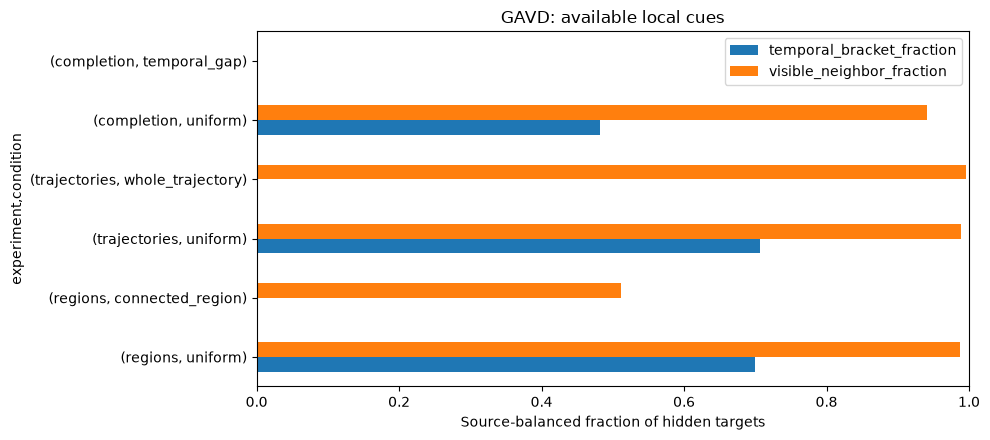

In [6]:
summary = structure_audit["summary"]
display(summary.groupby(["experiment", "condition"], sort=False).agg(
    smallest_realized_count=("hidden_min", "min"), largest_realized_count=("hidden_max", "max"),
    mean_hidden_fraction=("hidden_fraction", "mean"),
    temporal_brackets=("temporal_bracket_fraction", "mean"),
    visible_neighbors=("visible_neighbor_fraction", "mean")))
cue = summary.groupby(["experiment", "condition"], sort=False)[[
    "temporal_bracket_fraction", "visible_neighbor_fraction"]].mean()
ax = cue.plot.barh(figsize=(10, 4.5), xlim=(0, 1), title=f"{DATA_MODE.upper()}: available local cues")
ax.set_xlabel("Source-balanced fraction of hidden targets")
ax.figure.tight_layout(); display(ax.figure); plt.close(ax.figure)

## 5. Predeclare the next inference

Notebook 17's primary grid includes connected regions and the three
motion arms from Notebook 15. Trajectories and completion are declared
follow-ups; auditing them here does not claim they have been trained.
Add their experiment names to the configuration in both 17 and 18 to
conduct those comparisons.

If regions remove local cues yet fail to improve trained-over-initial
readout, cue removal alone is insufficient. If regions help against
their scattered reference and initial features, the trajectory follow-up
can distinguish spatial from temporal context effects. Avoid selecting
geometry by outer-test rank on this already inspected development cohort.

Interior gaps have context on both sides and test completion. Forecasting
requires the past-only inputs in Notebook 14. Removing prepared tokens
also differs from losing raw observations before interpolation and
normalization, addressed in Notebook 13. Continue with
[17](17_motion_and_structure_pretraining.ipynb) and
[18](18_motion_information_and_readout.ipynb).

## 6. Interpretation of the saved structure audit and next decision

**Evidence snapshot: 2026-09-08.** Executions 3–6 above retain the real GAVD
census, structure audit, example masks and cue plot. The audit visits
75,000 mask draws: 2,500 training-clip memberships across the five folds,
multiplied by five seeds and six experiment/arm combinations. These are
repeated draws from **625 clips and 93 videos**, not 75,000 independent
observations. The 17 excluded archives are QC attrition; the five dataset
condition counts describe this cohort and are not diagnostic outcomes.

### Step 1: Read the cue plot as a test of the intervention

| Experiment / arm | Observed target-count range | Mean hidden fraction | Immediate temporal brackets | Visible graph neighbor |
|---|---:|---:|---:|---:|
| Regions / uniform | 6–48 | 0.099 | 0.699 | 0.988 |
| Connected regions | 6–48 | 0.099 | 0.000 | 0.512 |
| Trajectories / uniform | 3–48 | 0.095 | 0.706 | 0.989 |
| Whole trajectories | 3–48 | 0.095 | 0.000 | 0.995 |
| Completion / uniform | 24–132 | 0.253 | 0.482 | 0.941 |
| Interior temporal gap | 24–132 | 0.253 | 0.000 | 0.000 |

Fractions use valid-token support and source-balanced summaries within
each fold/seed. A shorter bar means fewer of the specified local cues;
it does not by itself indicate a better learning problem.

Connected regions remove immediate two-sided temporal brackets and reduce
targets with a visible graph neighbor from **98.8% to 51.2%**, a decrease
of 47.6 percentage points. They still leave such a spatial cue for about
half of their targets. Whole trajectories remove the temporal brackets
while leaving a visible graph neighbor for **99.5%** of targets. They
isolate temporal removal more than spatial removal. Interior gaps remove
both measured local cues, but context still exists before and after the
gap. A zero bracket score concerns the two *immediately adjacent* blocks;
it does not mean that all temporal information has disappeared.

The six-panel example confirms the intended geometry on one identified
training clip. Scattered targets are dispersed; region targets span a
connected anatomical subset; trajectory targets extend across the clip;
the gap is one interior band. Anatomical connectivity follows the graph,
not adjacent landmark ID numbers. Gray cells are naturally missing, not
extra targets. The trajectory example has 45 targets because three of
its nominal 48 tokens fall in the missing first block. Its paired uniform
reference also has 45. The example's 48/45/132 counts are not cohort means.

### Step 2: Keep the comparisons that answer the same question

Regions and trajectories nominally hide 48 tokens, but missingness makes
their realized fractions differ. Completion hides about 25.3% of valid
tokens, versus about 9.5–9.9% for the other structures. Each structure
must be compared with its own count-matched uniform reference. Cross-family
scores would mix target amount and geometry. Similarly, the region-uniform
training arm is distinct from Notebook 15's higher-budget motion-uniform.

The smallest realized counts, 6/3/24, also show that some draws have much
less supervised support than their nominal structure. Per-clip loss
averaging preserves clip weight despite this variation. A useful future
audit should stratify error and target coverage by support, rather than
interpreting the nominal budget as a constant amount of information.

### Step 3: Connect cue removal to the completed learning result

Only **regions** from this notebook were trained in the primary grid.
Notebook 18's [saved teacher mean-motion comparison](artifacts/motion_structured/grids/292443b0fab5339f5da7ca566a85d6172ffc5b64abe5febf2546681a0152ff57/paired_intervals.csv)
gives R² **0.100777** for connected regions versus **0.109446** for their
uniform reference: difference **-0.008669**, with 95% source bootstrap
interval **[-0.033290, 0.017666]**. Both trail the matched initial encoder
(**0.222544**). The interval permits modest effects in either direction;
it supports neither a superiority claim nor an equivalence claim.

A small region-teacher mean-only increase over initial features
(**+0.002928 R²** averaged over seeds) does not rescue the hypothesis:
the temporal-summary contrast is **-0.121766**, negative in every seed.
The evidence shows that removing these local cues is insufficient for
a demonstrated benefit under this recipe and endpoint. It does not show
that structured masking cannot help a different task.

### Step 4: Proceed in this order

1. Diagnose the regularization and summary effects in Notebook 18 using
   the saved encoders. Keep regions as an informative completed comparison.
2. Defer a full trajectory/completion grid until a specific remaining
   hypothesis justifies it. Neither family has downstream results here.
3. If a focused context experiment is warranted, trajectories test whether
   retaining spatial neighbors while removing a landmark's time series
   changes the outcome. Completion addresses reconstruction with both
   earlier and later context. Predeclare that task and its controls.
4. Use Notebook 13 for observations removed before preparation and Notebook
   14 for past-only forecasting. The present figures support neither a
   raw-sensor robustness claim nor a future-prediction claim.

**Takeaway.** The geometry audit succeeded: the mask families leave
measurably different local information. The trained region comparison
provides no demonstrated readout advantage, so harder masks alone are
not the next priority.